In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksdistance import BlinkDistance

In [2]:
def generate_webgazer_dataframe(df):
    df1 = df[df["trial_type"] == "html-keyboard-response"]
    df_webgazer = df1[~df1["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        json_data = df_webgazer["webgazer_data"].iloc[row].replace("'", "\"")
        data_list = json.loads(json_data)
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)


In [3]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data/all-exp-separados/").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/all-exp-separados/dataframe_blink_22.csv
1944
data/all-exp-separados/dataframe_blink_9.csv
743
data/all-exp-separados/dataframe_blink_8.csv
1206
data/all-exp-separados/dataframe_blink_23.csv
1480
data/all-exp-separados/dataframe_blink_21.csv
1974
data/all-exp-separados/dataframe_blink_20.csv
1584
data/all-exp-separados/dataframe_blink_18.csv
2598
data/all-exp-separados/dataframe_blink_24.csv
1894
data/all-exp-separados/dataframe_blink_25.csv
1843
data/all-exp-separados/dataframe_blink_19.csv
785
data/all-exp-separados/dataframe_blink_17.csv
490
data/all-exp-separados/dataframe_blink_1.csv
1417
data/all-exp-separados/dataframe_blink_16.csv
1558
data/all-exp-separados/dataframe_blink_14.csv
1476
data/all-exp-separados/dataframe_blink_3.csv
2880
data/all-exp-separados/dataframe_blink_2.csv
2361
data/all-exp-separados/dataframe_blink_15.csv
1937
data/all-exp-separados/dataframe_blink_11.csv
2162
data/all-exp-separados/dataframe_blink_6.csv
1343
data/all-exp-separados/dataframe_blink_7

In [4]:
blinkDistance = distance.BlinkDistance()


df_webgazer["isBlinkByEar"] = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isBlinkByEar,isBlinkByDistance
0,0,0,6,"{'noseX': 299.44, 'noseY': 285.45, 'topY': 174...",59.37,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, True, True, True,...","[False, False, False, False, False, False, Fal..."
1,0,0,40,"{'noseX': 299.86, 'noseY': 284.82, 'topY': 174...",56.06,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,0,0,74,"{'noseX': 300.63, 'noseY': 285.45, 'topY': 173...",53.35,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,0,0,106,"{'noseX': 301.08, 'noseY': 285.31, 'topY': 173...",51.42,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
4,0,0,141,"{'noseX': 301.66, 'noseY': 285.31, 'topY': 173...",50.71,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...,...
251,0,0,8543,"{'noseX': 390, 'noseY': 299.17, 'topY': 162.47...",42.36,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
252,0,0,8578,"{'noseX': 386.91, 'noseY': 297.21, 'topY': 161...",43.42,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
253,0,0,8612,"{'noseX': 381.07, 'noseY': 298.49, 'topY': 161...",41.85,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
254,0,0,8644,"{'noseX': 377.21, 'noseY': 297.19, 'topY': 160...",40.99,6,24,data/all-exp-separados/dataframe_blink_13.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."


In [5]:
df_webgazer.head()

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isBlinkByEar,isBlinkByDistance
0,0,0,6,"{'noseX': 299.44, 'noseY': 285.45, 'topY': 174...",59.37,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, True, True, True,...","[False, False, False, False, False, False, Fal..."
1,0,0,40,"{'noseX': 299.86, 'noseY': 284.82, 'topY': 174...",56.06,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,0,0,74,"{'noseX': 300.63, 'noseY': 285.45, 'topY': 173...",53.35,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,0,0,106,"{'noseX': 301.08, 'noseY': 285.31, 'topY': 173...",51.42,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
4,0,0,141,"{'noseX': 301.66, 'noseY': 285.31, 'topY': 173...",50.71,1,0,data/all-exp-separados/dataframe_blink_22.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."


In [ ]:
threshold_columns = [col for col in result.columns if col not in ['trial', 'file_name']]
result['should_be'] = result['trial'].apply(lambda x: 2 if x == 3 else 10)
result[result['trial']==3]


In [14]:
 #resultados por participante blink ear
df_webgazer["Blink_sample_ear"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[14]==True))
df_webgazer["Blink_sample_ear_diff"] = (df_webgazer['Blink_sample_ear'].shift(1)+1 == df_webgazer['Blink_sample_ear'])


result_per_participant_ear = df_webgazer.groupby(['file_name'])['Blink_sample_ear_diff'].sum().reset_index()
result_per_participant_ear

,file_name,Blink_sample_ear_diff
0,data/all-exp-separados/dataframe_blink_1.csv,53
1,data/all-exp-separados/dataframe_blink_10.csv,0
2,data/all-exp-separados/dataframe_blink_11.csv,53
3,data/all-exp-separados/dataframe_blink_12.csv,50
4,data/all-exp-separados/dataframe_blink_13.csv,65
5,data/all-exp-separados/dataframe_blink_14.csv,57
6,data/all-exp-separados/dataframe_blink_15.csv,67
7,data/all-exp-separados/dataframe_blink_16.csv,59
8,data/all-exp-separados/dataframe_blink_17.csv,57
9,data/all-exp-separados/dataframe_blink_18.csv,0


In [15]:
 #resultados por participante blink distance
df_webgazer["Blink_sample_dist"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample_dist_diff"] = (df_webgazer['Blink_sample_dist'].shift(1)+1 == df_webgazer['Blink_sample_dist'])


result_per_participant_dist = df_webgazer.groupby(['file_name'])['Blink_sample_dist_diff'].sum().reset_index()
result_per_participant_dist

,file_name,Blink_sample_dist_diff
0,data/all-exp-separados/dataframe_blink_1.csv,53
1,data/all-exp-separados/dataframe_blink_10.csv,1
2,data/all-exp-separados/dataframe_blink_11.csv,53
3,data/all-exp-separados/dataframe_blink_12.csv,9
4,data/all-exp-separados/dataframe_blink_13.csv,65
5,data/all-exp-separados/dataframe_blink_14.csv,62
6,data/all-exp-separados/dataframe_blink_15.csv,55
7,data/all-exp-separados/dataframe_blink_16.csv,47
8,data/all-exp-separados/dataframe_blink_17.csv,50
9,data/all-exp-separados/dataframe_blink_18.csv,0


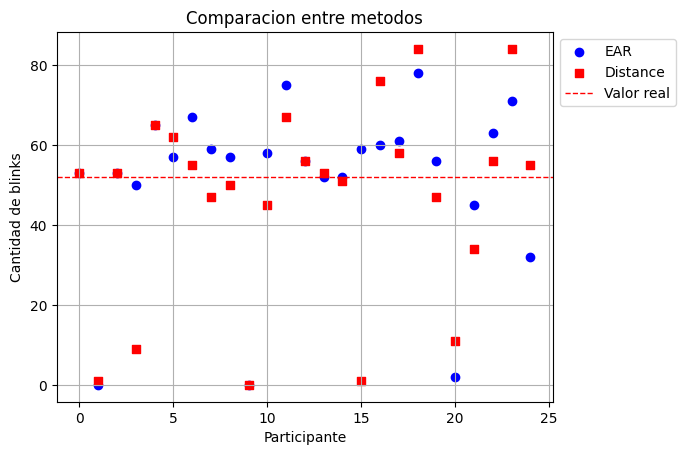

In [8]:
result_per_participant_ear
result_per_participant_dist


plt.scatter(list(range(25)), result_per_participant_ear['Blink_sample_ear_diff'], marker='o', color='blue', label='EAR')  # círculo
plt.scatter(list(range(25)), result_per_participant_dist['Blink_sample_dist_diff'], marker='s', color='red', label='Distance')   # cuadrado

plt.axhline(y=52, color="red", linestyle="--", lw=1, label= "Valor real")

plt.xlabel('Participante')
plt.ylabel('Cantidad de blinks')
plt.title('Comparacion entre metodos')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)  # Leyenda fuera del gráfico
plt.grid(True)  # Activar la cuadrícula

# Mostrar
plt.show()


In [19]:
 #resultados por participante por trial blink ear
df_webgazer["Blink_sample_ear"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[14]==True))
df_webgazer["Blink_sample_ear_diff"] = (df_webgazer['Blink_sample_ear'].shift(1)+1 == df_webgazer['Blink_sample_ear'])


result_per_participant_ear = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_ear_diff'].sum().reset_index()
result_per_participant_ear


,file_name,trial,Blink_sample_ear_diff
0,data/all-exp-separados/dataframe_blink_1.csv,1,10
1,data/all-exp-separados/dataframe_blink_1.csv,2,10
2,data/all-exp-separados/dataframe_blink_1.csv,3,10
3,data/all-exp-separados/dataframe_blink_1.csv,4,10
4,data/all-exp-separados/dataframe_blink_1.csv,5,10
...,...,...,...
145,data/all-exp-separados/dataframe_blink_9.csv,2,2
146,data/all-exp-separados/dataframe_blink_9.csv,3,2
147,data/all-exp-separados/dataframe_blink_9.csv,4,0
148,data/all-exp-separados/dataframe_blink_9.csv,5,8


In [20]:
 #resultados por participante por trial blink distance
df_webgazer["Blink_sample_dist"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample_dist_diff"] = (df_webgazer['Blink_sample_dist'].shift(1)+1 == df_webgazer['Blink_sample_dist'])


result_per_participant_dist = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_dist_diff'].sum().reset_index()
result_per_participant_dist

,file_name,trial,Blink_sample_dist_diff
0,data/all-exp-separados/dataframe_blink_1.csv,1,10
1,data/all-exp-separados/dataframe_blink_1.csv,2,11
2,data/all-exp-separados/dataframe_blink_1.csv,3,10
3,data/all-exp-separados/dataframe_blink_1.csv,4,10
4,data/all-exp-separados/dataframe_blink_1.csv,5,10
...,...,...,...
145,data/all-exp-separados/dataframe_blink_9.csv,2,8
146,data/all-exp-separados/dataframe_blink_9.csv,3,10
147,data/all-exp-separados/dataframe_blink_9.csv,4,4
148,data/all-exp-separados/dataframe_blink_9.csv,5,10


In [22]:
result_per_participant_ear
result_per_participant_dist

result_ear = result_per_participant_ear[result_per_participant_ear["Blink_sample_ear_diff"]>0]
result_dist = result_per_participant_dist[result_per_participant_dist["Blink_sample_dist_diff"]>0]

result_dist['error'] = np.where(
    result_dist['trial'] == 3,
    np.abs(result_dist['Blink_sample_dist_diff'] - 2),
    np.abs(result_dist['Blink_sample_dist_diff'] - 10)
)

result_ear['error'] = np.where(
    result_ear['trial'] == 3,
    np.abs(result_ear['Blink_sample_ear_diff'] - 2),
    np.abs(result_ear['Blink_sample_ear_diff'] - 10)
)

result_ear['metodo'] = 'ear'
result_dist['metodo'] = 'dist'

combined_df = pd.concat([result_ear, result_dist])

result_df = combined_df[['error', 'metodo']]
##print(result_df)

result_df.filter

agrupado = result_df.groupby('metodo')['error'].agg(['mean', 'std'])

print(agrupado)



            mean       std
metodo                    
dist    2.891473  4.883391
ear     2.067669  2.995440


/var/folders/bc/dx7gzw5x0d9_snwy574lpzc40000gn/T/ipykernel_708/440014315.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dist['error'] = np.where(
/var/folders/bc/dx7gzw5x0d9_snwy574lpzc40000gn/T/ipykernel_708/440014315.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_ear['error'] = np.where(
/var/folders/bc/dx7gzw5x0d9_snwy574lpzc40000gn/T/ipykernel_708/440014315.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [12]:

combined_df

,file_name,trial,Blink_sample_ear_diff,error,metodo,Blink_sample_dist_diff
0,data/all-exp-separados/dataframe_blink_1.csv,1,10.0,0,ear,NaN
1,data/all-exp-separados/dataframe_blink_1.csv,2,10.0,0,ear,NaN
2,data/all-exp-separados/dataframe_blink_1.csv,3,10.0,8,ear,NaN
3,data/all-exp-separados/dataframe_blink_1.csv,4,10.0,0,ear,NaN
4,data/all-exp-separados/dataframe_blink_1.csv,5,10.0,0,ear,NaN
...,...,...,...,...,...,...
145,data/all-exp-separados/dataframe_blink_9.csv,2,NaN,2,dist,8.0
146,data/all-exp-separados/dataframe_blink_9.csv,3,NaN,8,dist,10.0
147,data/all-exp-separados/dataframe_blink_9.csv,4,NaN,6,dist,4.0
148,data/all-exp-separados/dataframe_blink_9.csv,5,NaN,0,dist,10.0


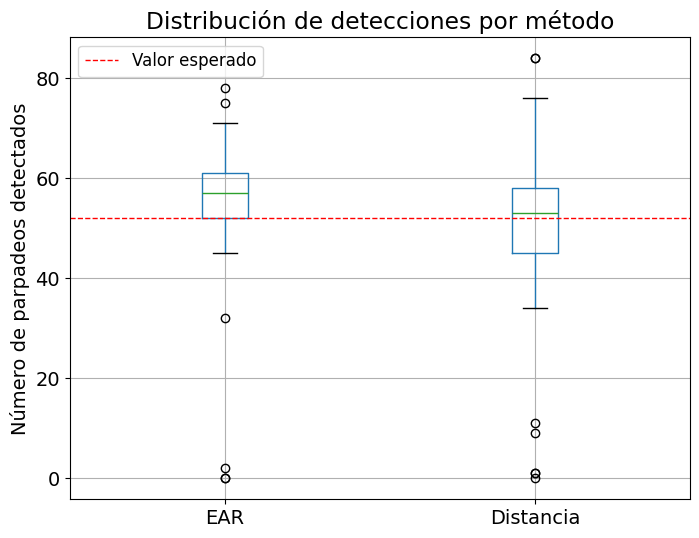

In [18]:

# Unimos los datos en un único DataFrame para facilitar el boxplot
data = pd.DataFrame({
    'EAR': result_per_participant_ear['Blink_sample_ear_diff'],
    'Distancia': result_per_participant_dist['Blink_sample_dist_diff'],
})

plt.rcParams['font.size'] = 14

# Generar boxplot
ax = data.boxplot(column=['EAR', 'Distancia'],
                  grid=True, figsize=(8,6))

plt.axhline(y=52, color="red", linestyle="--", lw=1, label= "Valor esperado")
plt.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize=12)  # Leyenda fuera del gráfico

plt.ylabel('Número de parpadeos detectados')
plt.title('Distribución de detecciones por método')
plt.show()


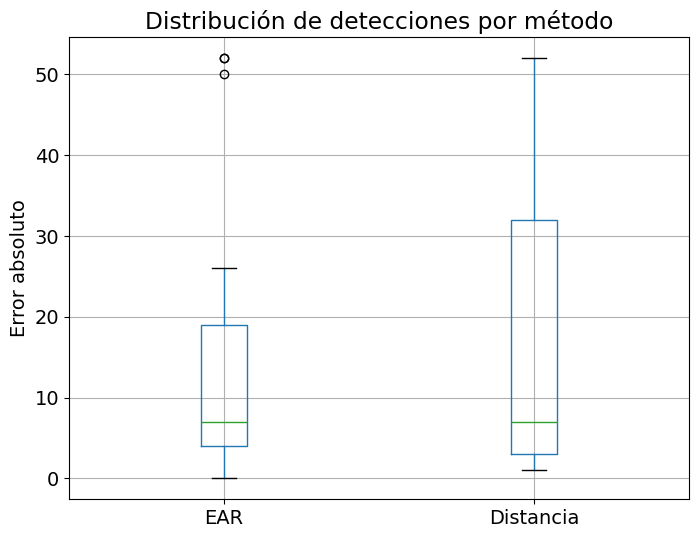

In [16]:
#Boxplot con error en vez de cant de blinks
valor_esperado = 52

data = pd.DataFrame({
    'EAR': abs(result_per_participant_ear['Blink_sample_ear_diff'] - valor_esperado),
    'Distancia': abs(result_per_participant_dist['Blink_sample_dist_diff'] - valor_esperado),
})

plt.rcParams['font.size'] = 14

# Generar boxplot
ax = data.boxplot(column=['EAR', 'Distancia'],
                  grid=True, figsize=(8,6))

plt.ylabel('Error absoluto')
plt.title('Distribución de detecciones por método')
plt.show()